In [7]:
%matplotlib widget
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, interpolate
from scipy.signal import medfilt
from astropy.io import fits
from astropy import units as u
import pandas as pd
from lightkurve.periodogram import BoxLeastSquaresPeriodogram
import warnings
warnings.filterwarnings('ignore')
import os

In [14]:
#TIC = 'TIC 169716484'   #2018
#TIC = 'TIC 284475976'   #example
TIC = 'TIC 169716005'
sector_data = lk.search_lightcurve(TIC)[3]                   #2018 
#sector_data = lk.search_lightcurve(TIC, author = 'SPOC', sector = 23)   #example

lc = sector_data.download()
sector_data


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 07,2019,TGLC,1800,169716005,0.0


In [15]:
def plot_bls(alltime, allflux, alltimebinned, allfluxbinned, model, results, period, duration, t0, mid_transit_t0, in_transit):
    """
    Plot the BLS. This function is called in data_bls().
    """
    color1 = 'deepskyblue'
    color2 = '#4682B4'
    title = 'Event Light Curve' 
    
    fig, axes = plt.subplots(3, 1, figsize=(8, 10))
    
    # --- axes[0]: Plot the Periodogram ---
    ax = axes[0]
    ax.axvline(period, alpha=0.4, lw=5, color=color1)
    for n in range(2, 15):
        ax.axvline(n*period, alpha=0.4, lw=2, linestyle="dashed", color=color2)
        ax.axvline(period / n, alpha=0.4, lw=2, linestyle="dashed", color=color2)
        
    ax.plot(results.period, results.power, "k", lw=0.5, label=f'P = {period:.3f} T0 = {mid_transit_t0:.3f}')
    ax.set_title(title)
    ax.set_xlim(results.period.min(), results.period.max())
    ax.set_xlabel("period (days)")
    ax.set_ylabel("log likelihood")
    ax.legend(fontsize=10, loc=1)
    
    # --- axes[1]: Plot the light curve and best-fit model ---
    ax = axes[1]
    if len(in_transit) == 1: # For the initial run
        ax.plot(alltime, allflux, marker=".", alpha=0.4, color=color2, ms=2, lw=0)
        ax.plot(alltimebinned, allfluxbinned, marker="o", alpha=0.6, color='black', ms=3, lw=0)
    else: # For the second run
        ax.plot(alltime[~in_transit_notbinned], allflux[~in_transit_notbinned], marker=".", alpha=0.4, color=color2, ms=2, lw=0)
        ax.plot(alltimebinned[~in_transit], allfluxbinned[~in_transit], marker="o", alpha=0.6, color='black', ms=3, lw=0)
    
    x = np.linspace(alltimebinned.min(), alltimebinned.max(), 3*len(alltimebinned))
    f = model.model(x, period, duration, t0)
    ax.plot(x, f, lw=2, color=color1)
    ax.set_xlim(alltimebinned.min(), alltimebinned.max())
    ax.set_xlabel("time (days)")
    ax.set_ylabel("de-trended flux (ppt)")
    
    # --- axes[2]: Phased light curve ---
    ax = axes[2]
    # Phasing logic
    x_binned = (alltimebinned - t0 + 0.5*period) % period - 0.5*period
    # (Plotting code continues for phased view as seen in Screenshot 211251)
    ax.plot(x_binned, allfluxbinned, "o", alpha=0.6, color='black', ms=3, lw=0)
    
    x = np.linspace(-0.5, 0.5, 1000)
    f = model.model(x + t0, period, duration, t0)
    ax.plot(x, f, lw=2, color=color1)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xlabel("Time since transit (days)")
    ax.set_ylabel("de-trended flux (ppt)")
    
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join('/Users/mrvarshney/Codes/ARIES/bls_outputs', f"{TIC}.png"), dpi=150)


In [16]:
def data_bls(lc):
    """
    Function that runs the BLS routine twice and plots the results.
    """
    try:
        lc = lc.normalize()
    except:
        pass
        
    alltime = lc.time.value
    allflux = lc.flux.value
    
    # Binning the data
    lc_bin = lc.bin(15/60/24) # Binning factor
    alltimebinned = lc_bin.time.value
    allfluxbinned = lc_bin.flux.value
    
    # Clean NaN values
    mask_binned = np.isfinite(alltimebinned) * np.isfinite(allfluxbinned)
    alltimebinned = np.array(alltimebinned)[mask_binned]
    allfluxbinned = np.array(allfluxbinned)[mask_binned]
    
    # Detrend data and set BLS parameters
    durations = np.linspace(0.05, 0.5, 15)
    periods = np.arange(0.7, (np.nanmax(alltimebinned) - np.nanmin(alltimebinned)), 0.01)
    
    # First BLS Run
    model = lk.periodogram.BoxLeastSquares(alltimebinned, allfluxbinned)
    results = model.power(periods, durations)
    
    index = np.argmax(results.power)
    period = results.period[index]
    t0 = results.transit_time[index]
    duration = results.duration[index]
    mid_transit_t0 = model.compute_stats(period, duration, t0)['transit_times'][0]
    
    # Plot First Run
    plot_bls(alltime, allflux, alltimebinned, allfluxbinned, model, results, period, duration, t0, mid_transit_t0, [0])
    
    # Save stats
    stats_period = period
    stats_t0 = mid_transit_t0
    stats_depth = model.compute_stats(period, duration, t0)['depth']
    stats_depth_phased = model.compute_stats(period, duration, t0)['depth_half']
    stats_depth_half = model.compute_stats(period, duration, t0)['depth_half']
    stats_depth_odd = model.compute_stats(period, duration, t0)['depth_odd']
    stats_depth_even = model.compute_stats(period, duration, t0)['depth_even']

    if (1*duration) >= period: # if the 'found' events are very short period, don't run the BLS twice
        return [stats_period, stats_t0, stats_depth, stats_depth_phased, stats_depth_half, stats_depth_odd, stats_depth_even]

    # Find the in-transit points using a longer duration as a buffer to avoid ingress and egress
    in_transit = model.transit_mask(alltimebinned, period, 2*duration, t0)
    in_transit_notbinned = model.transit_mask(alltime, period, 2*duration, t0)

    # Re-run the algorithm, and plot the results
    # Use the mask to ignore the data from the first planet found
    model2 = BoxLeastSquares(alltimebinned[~in_transit], allfluxbinned[~in_transit])
    results2 = model2.power(periods, durations)

    # Extract the parameters of the best-fit model from the second run
    index = np.argmax(results2.power)
    period2 = results2.period[index]
    t02 = results2.transit_time[index]
    duration2 = results2.duration[index]
    mid_transit_t02 = model.compute_stats(period2, duration2, t02)['transit_times'][0]

    # Call the second round of plotting - once the initial transit has been removed
    plot_bls(alltime, allflux, alltimebinned, allfluxbinned, model2, results2, period2, duration2, t02, mid_transit_t02, in_transit)

    # Collect statistics for the second fit
    stats2_period = period2
    stats2_t0 = mid_transit_t02
    stats2_depth = model2.compute_stats(period2, duration2, t0)['depth']
    stats2_depth_phased = model2.compute_stats(period2, duration2, t0)['depth_phased']
    stats2_depth_half = model2.compute_stats(period2, duration2, t0)['depth_half']
    stats2_depth_odd = model2.compute_stats(period2, duration2, t0)['depth_odd']
    stats2_depth_even = model2.compute_stats(period2, duration2, t0)['depth_even']

    # Compile the primary results into a DataFrame
    df = pd.DataFrame({
        "Period (days)": [stats_period, stats2_period], 
        "T0 (TBJD)": [stats_t0, stats2_t0], 
        "Transit depth": [stats_depth, stats2_depth]
    })
    
    return df

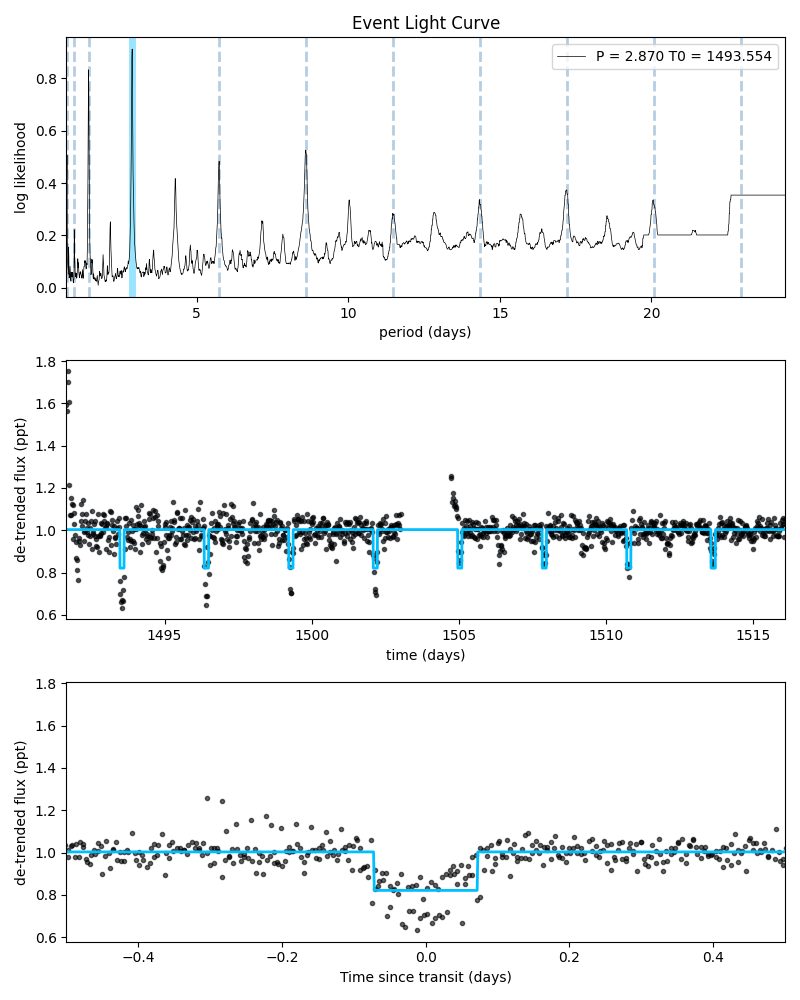

NameError: name 'BoxLeastSquares' is not defined

In [17]:
df = data_bls(lc)

print("Some statistics about the two fits:")
print(df)
import os
